# 🏦 Bank Cash Optimization — Phase 3: Model Preparation

---

**Project:** Bank Cash Optimization  
**Notebook:** 03_Model_Preparation  
**Author:** Abdul Qadeer  

## 🎯 Objective

This notebook prepares the feature-engineered dataset for **Time Series Forecasting** model training.

**This notebook covers:**
1. Load feature-engineered dataset
2. Define target variable & problem statement
3. Aggregate data to Daily Branch level (correct granularity for forecasting)
4. Chronological Train/Test Split (80/20) — for model validation only
5. Feature & Target separation (X, y)
6. Verify no data leakage
7. Save train/test splits for model training

> **Note:** 80/20 split is **only for validation** (checking model accuracy).  
> Final production model will be trained on **100% of historical data** to predict future cash needs.


---
## Step 1 — Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import joblib
import os

# ── Display Config ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.width', 150)

plt.rcParams.update({
    'figure.dpi'        : 130,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F9FAFB',
    'axes.grid'         : True,
    'grid.color'        : '#E5E7EB',
})

os.makedirs('model_data', exist_ok=True)
print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


---
## Step 2 — Load Feature-Engineered Dataset

In [2]:
df = pd.read_csv('bank_cash_optimization_features.csv')
df['start_date'] = pd.to_datetime(df['start_date'])

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'📅 Date range   : {df["start_date"].min().date()}  →  {df["start_date"].max().date()}')
print(f'🏦 Branches     : {df["tran_br_code"].nunique()} unique branches')
print(f'❌ Missing values: {df.isnull().sum().sum()}')
df.head(3)

✅ Dataset loaded: 81,709 rows × 41 columns
📅 Date range   : 2024-01-02  →  2026-04-04
🏦 Branches     : 15 unique branches
❌ Missing values: 0


,start_date,tran_br_code,txn_hour,TOTAL_DR,TOTAL_CR,Total_Cash_Movement,Net_Cash_Flow,Debit_Credit_Ratio,Branch_Hourly_Debit,Branch_Hourly_Credit,Branch_Hourly_Txn_Count,Is_Net_Outflow,Hourly_Txn_Count,Hourly_Total_Credit,Hourly_Total_Debit,Hourly_Avg_Credit,Hourly_Avg_Debit,Hour_Cos,Is_Business_Hour,Branch_Total_Debit,Branch_Txn_Count,Branch_Avg_Net_Cash_Flow,Branch_Daily_Debit,Is_Peak_Hour,Branch_Daily_Txn_Count,Branch_Daily_Credit,Weekday,Weekday_Sin,Weekday_Cos,Is_Weekend,Month_Sin,Year,Month_Cos,Month,Daily_Txn_Count,Day,Monthly_Total_Debit,Monthly_Txn_Count,Daily_Total_Debit,Daily_Total_Credit,Daily_Net_Cash_Flow
0,2025-12-01,104,17,"52,041,400.00","55,380,056.00","107,421,460.00","3,338,656.00",0.94,"14,034,273.00","13,522,964.00",552,0,7368,"40,230,072,000.00","50,916,850,000.00","5,460,107.50","6,910,539.00",-0.26,0,"74,641,180,000.00",6558,"-126,521.54","116,258,740.00",0,10,"121,649,510.00",0,0.00,1.00,0,-0.00,2025,1.00,12,150,1,"16,368,400,000.00",3314,"949,430,000.00","895,837,250.00","-53,592,736.00"
1,2026-03-24,104,15,"52,041,400.00","55,380,056.00","107,421,460.00","3,338,656.00",0.94,"13,360,758.00","10,441,775.00",657,0,8390,"49,132,140,000.00","56,288,883,000.00","5,856,035.50","6,709,044.50",-0.71,1,"74,641,180,000.00",6558,"-126,521.54","231,977,820.00",1,10,"191,959,950.00",1,0.78,0.62,0,1.00,2026,0.00,3,141,24,"14,314,524,000.00",2345,"1,101,870,000.00","734,359,100.00","-367,510,800.00"
2,2024-02-02,104,12,"52,041,400.00","55,380,056.00","107,421,460.00","3,338,656.00",0.94,"12,030,818.00","13,562,067.00",664,0,8980,"54,456,020,000.00","42,279,790,000.00","6,064,145.00","4,708,217.00",-1.00,1,"74,641,180,000.00",6558,"-126,521.54","160,237,300.00",1,12,"174,547,060.00",4,-0.43,-0.90,0,0.87,2024,0.50,2,157,2,"14,089,429,000.00",2809,"874,701,440.00","985,057,860.00","110,356,420.00"


---
## Step 3 — Define Problem Statement & Target Variable

### 🎯 What are we predicting?

| | |
|---|---|
| **Target (y)** | `Daily_Total_Debit` — Total cash withdrawn per branch per day (PKR) |
| **Why Debit?** | Debit = Cash Outflow = What the bank needs to replenish |
| **Granularity** | One row = One Branch + One Day |
| **Model Type** | Supervised Regression (Time Series Forecasting) |

> **Business Meaning:** If we can predict how much cash will be withdrawn from Branch X on Day Y, the bank can ensure enough cash is available — reducing both cash shortages AND excess idle cash.

---
## Step 4 — Aggregate to Daily Branch Level

Current dataset is at **transaction level** (each row = one transaction).  
For forecasting, we need **daily level** (each row = one branch + one day).

In [3]:
daily = df.groupby(['start_date', 'tran_br_code']).agg(
    # ── Target ────────────────────────────────────────────────────
    Daily_Total_Debit      = ('TOTAL_DR',              'sum'),
    Daily_Total_Credit     = ('TOTAL_CR',              'sum'),
    # ── Transaction Volume ─────────────────────────────────────────
    Daily_Txn_Count        = ('TOTAL_DR',              'count'),
    # ── Time Features ─────────────────────────────────────────────
    Weekday                = ('Weekday',               'first'),
    Is_Weekend             = ('Is_Weekend',            'first'),
    Month                  = ('Month',                 'first'),
    Year                   = ('Year',                  'first'),
    Day                    = ('Day',                   'first'),
    Weekday_Sin            = ('Weekday_Sin',           'first'),
    Weekday_Cos            = ('Weekday_Cos',           'first'),
    Month_Sin              = ('Month_Sin',             'first'),
    Month_Cos              = ('Month_Cos',             'first'),
    # ── Branch Level Features ──────────────────────────────────────
    Branch_Total_Debit     = ('Branch_Total_Debit',    'first'),
    Branch_Txn_Count       = ('Branch_Txn_Count',      'first'),
    Branch_Avg_Net_CF      = ('Branch_Avg_Net_Cash_Flow','first'),
    # ── Hourly Patterns ───────────────────────────────────────────
    Peak_Hour_Txns         = ('Is_Peak_Hour',          'sum'),
    Business_Hour_Txns     = ('Is_Business_Hour',      'sum'),
    # ── Net Cash Flow ──────────────────────────────────────────────
    Daily_Net_Cash_Flow    = ('Net_Cash_Flow',         'sum'),
    Net_Outflow_Periods    = ('Is_Net_Outflow',        'sum'),
).reset_index()

# Sort chronologically — CRITICAL for time series
daily = daily.sort_values(['start_date', 'tran_br_code']).reset_index(drop=True)

print(f'✅ Daily-branch dataset: {daily.shape[0]:,} rows × {daily.shape[1]} columns')
print(f'📅 Date range: {daily["start_date"].min().date()}  →  {daily["start_date"].max().date()}')
print(f'🏦 Branches  : {daily["tran_br_code"].nunique()}')
daily.head()

✅ Daily-branch dataset: 9,032 rows × 21 columns
📅 Date range: 2024-01-02  →  2026-04-04
🏦 Branches  : 15


,start_date,tran_br_code,Daily_Total_Debit,Daily_Total_Credit,Daily_Txn_Count,Weekday,Is_Weekend,Month,Year,Day,Weekday_Sin,Weekday_Cos,Month_Sin,Month_Cos,Branch_Total_Debit,Branch_Txn_Count,Branch_Avg_Net_CF,Peak_Hour_Txns,Business_Hour_Txns,Daily_Net_Cash_Flow,Net_Outflow_Periods
0,2024-01-02,104,"257,889,850.00","229,779,631.00",11,1,0,1,2024,2,0.78,0.62,0.50,0.87,"74,641,180,000.00",6558,"-126,521.54",5,8,"-28,110,213.00",6
1,2024-01-02,202,"36,746,669.00","36,241,366.00",9,1,0,1,2024,2,0.78,0.62,0.50,0.87,"22,329,573,000.00",5134,"-12,036.74",5,8,"-505,303.00",5
2,2024-01-02,234,"38,943,106.00","41,637,007.00",10,1,0,1,2024,2,0.78,0.62,0.50,0.87,"24,130,638,000.00",5305,"4,948.50",5,8,"2,693,901.00",4
3,2024-01-02,287,"46,889,763.00","46,470,286.00",10,1,0,1,2024,2,0.78,0.62,0.50,0.87,"14,088,423,000.00",5073,"-6,448.90",5,8,"-419,478.00",3
4,2024-01-02,372,"26,434,455.00","34,072,734.00",11,1,0,1,2024,2,0.78,0.62,0.50,0.87,"19,244,601,000.00",5127,-175.76,5,8,"7,638,279.00",5


---
## Step 5 — Add Lag Features (Key for Time Series Forecasting)

Lag features = **pichle dinon ki values** — model ko history dikhate hain.

| Feature | Meaning |
|---|---|
| `lag_1` | Yesterday's debit |
| `lag_7` | Same day last week's debit |
| `lag_14` | 2 weeks ago same day |
| `lag_30` | 1 month ago same day |
| `rolling_7_mean` | 7-day average debit |
| `rolling_30_mean` | 30-day average debit |

In [4]:
# Add lag features per branch (shift within each branch's time series)
daily = daily.sort_values(['tran_br_code', 'start_date']).reset_index(drop=True)

for lag in [1, 7, 14, 30]:
    daily[f'lag_{lag}_debit'] = (
        daily.groupby('tran_br_code')['Daily_Total_Debit']
        .shift(lag)
    )

# Rolling averages (smoothed historical trend)
daily['rolling_7_mean_debit'] = (
    daily.groupby('tran_br_code')['Daily_Total_Debit']
    .shift(1)
    .rolling(window=7, min_periods=1)
    .mean()
    .values
)
daily['rolling_30_mean_debit'] = (
    daily.groupby('tran_br_code')['Daily_Total_Debit']
    .shift(1)
    .rolling(window=30, min_periods=1)
    .mean()
    .values
)

print(f'✅ Lag features added')
print(f'   Lag features: lag_1, lag_7, lag_14, lag_30, rolling_7_mean, rolling_30_mean')

# Rows with NaN lags (first few days per branch) — drop them
before = len(daily)
daily = daily.dropna(subset=['lag_30_debit']).reset_index(drop=True)
after  = len(daily)
print(f'   Dropped {before - after} rows (insufficient lag history) — {after:,} rows remaining')

✅ Lag features added
   Lag features: lag_1, lag_7, lag_14, lag_30, rolling_7_mean, rolling_30_mean
   Dropped 450 rows (insufficient lag history) — 8,582 rows remaining


---
## Step 6 — Feature & Target Separation

In [5]:
# Columns to EXCLUDE from features
drop_cols = [
    'start_date',          # Not a numeric feature (used for split)
    'Daily_Total_Debit',   # This is our TARGET — never use as feature
    'Daily_Total_Credit',  # Highly correlated with target, causes leakage
    'Daily_Net_Cash_Flow', # Contains target info (DR - CR)
    'Net_Outflow_Periods', # Derived from target
]

feature_cols = [c for c in daily.columns if c not in drop_cols]
TARGET       = 'Daily_Total_Debit'

print(f'✅ Target variable : {TARGET}')
print(f'✅ Total features  : {len(feature_cols)}')
print(f'\n📋 Feature List:')
for i, col in enumerate(feature_cols, 1):
    print(f'   {i:2d}. {col}')

✅ Target variable : Daily_Total_Debit
✅ Total features  : 22

📋 Feature List:
    1. tran_br_code
    2. Daily_Txn_Count
    3. Weekday
    4. Is_Weekend
    5. Month
    6. Year
    7. Day
    8. Weekday_Sin
    9. Weekday_Cos
   10. Month_Sin
   11. Month_Cos
   12. Branch_Total_Debit
   13. Branch_Txn_Count
   14. Branch_Avg_Net_CF
   15. Peak_Hour_Txns
   16. Business_Hour_Txns
   17. lag_1_debit
   18. lag_7_debit
   19. lag_14_debit
   20. lag_30_debit
   21. rolling_7_mean_debit
   22. rolling_30_mean_debit


---
## Step 7 — Chronological Train/Test Split

⚠️ **Important:** In Time Series, we NEVER shuffle the data.

```
|←────────── TRAIN (80%) ──────────→|←── TEST (20%) ──→|
|  Jan 2024 ────────── Oct 2025     | Nov 2025 → Apr 2026|
      (Model seekhega)                  (Model test hoga)
```

> **This split is ONLY for evaluating model accuracy.**  
> Final model will train on 100% data to predict real future.

In [6]:
# Sort chronologically before split
daily = daily.sort_values('start_date').reset_index(drop=True)

# 80/20 cutoff by date
cutoff_idx  = int(len(daily) * 0.80)
cutoff_date = daily.iloc[cutoff_idx]['start_date']

train_df = daily[daily['start_date'] <  cutoff_date].reset_index(drop=True)
test_df  = daily[daily['start_date'] >= cutoff_date].reset_index(drop=True)

X_train = train_df[feature_cols]
y_train = train_df[TARGET]
X_test  = test_df[feature_cols]
y_test  = test_df[TARGET]

print(f'📅 Train period : {train_df["start_date"].min().date()}  →  {train_df["start_date"].max().date()}')
print(f'📅 Test period  : {test_df["start_date"].min().date()}  →  {test_df["start_date"].max().date()}')
print(f'\n📦 Train size   : {len(X_train):,} rows  ({len(X_train)/len(daily)*100:.1f}%)')
print(f'📦 Test size    : {len(X_test):,} rows  ({len(X_test)/len(daily)*100:.1f}%)')
print(f'\n✅ NO SHUFFLE — Pure chronological split (no data leakage)')

📅 Train period : 2024-02-07  →  2025-10-28
📅 Test period  : 2025-10-29  →  2026-04-04

📦 Train size   : 6,851 rows  (79.8%)
📦 Test size    : 1,731 rows  (20.2%)

✅ NO SHUFFLE — Pure chronological split (no data leakage)


---
## Step 8 — Visualize Train/Test Split

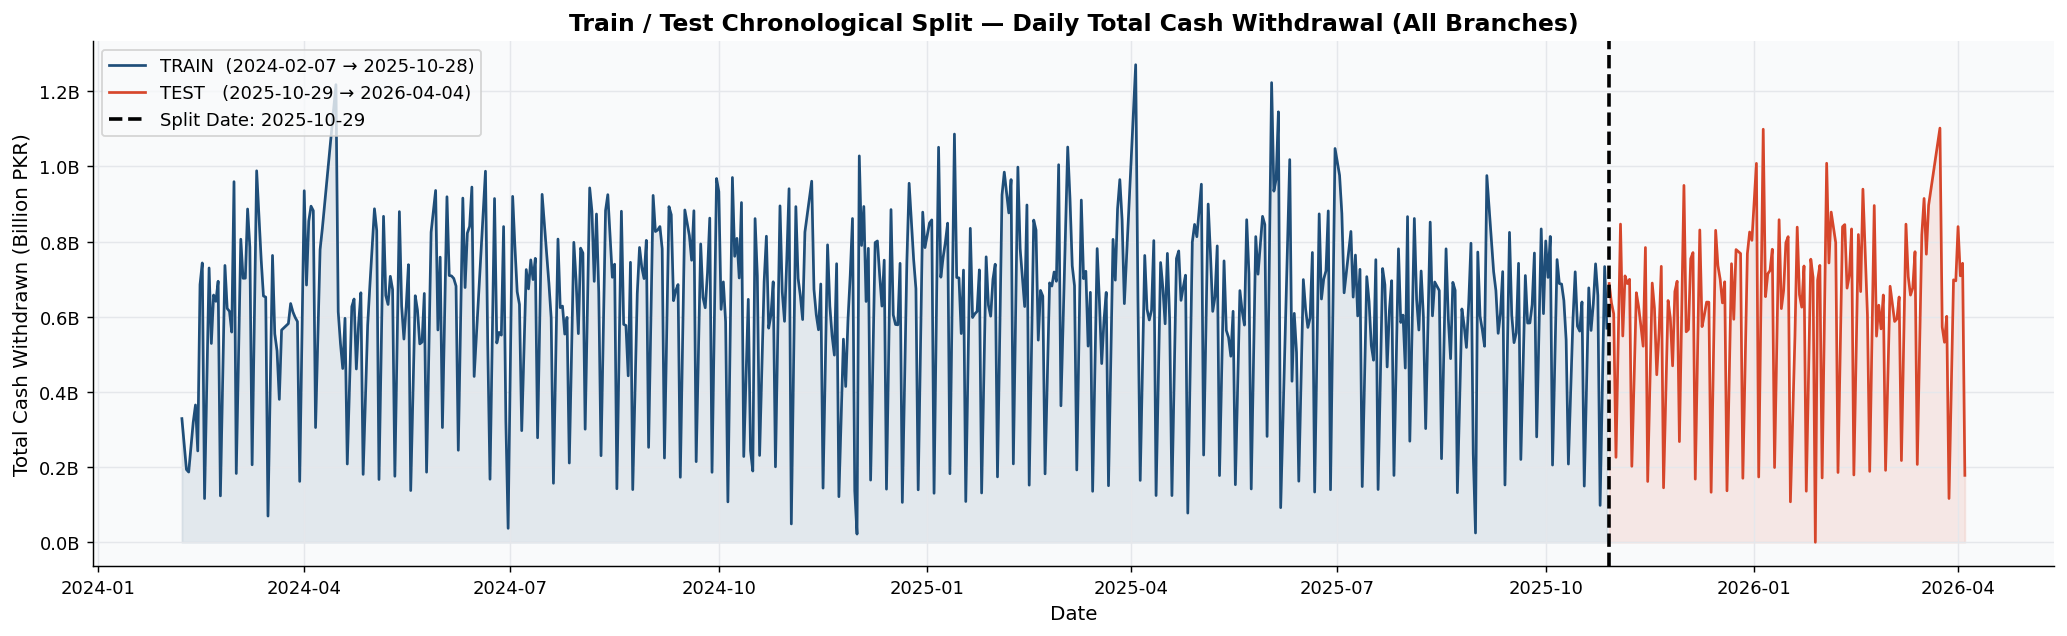

✅ Split visualization saved.


In [7]:
fig, ax = plt.subplots(figsize=(16, 5))

# Aggregate daily total debit across all branches
train_agg = train_df.groupby('start_date')['Daily_Total_Debit'].sum()
test_agg  = test_df.groupby('start_date')['Daily_Total_Debit'].sum()

ax.plot(train_agg.index, train_agg.values / 1e9, color='#1F4E79', linewidth=1.5,
        label=f'TRAIN  ({train_df["start_date"].min().date()} → {train_df["start_date"].max().date()})')
ax.plot(test_agg.index,  test_agg.values  / 1e9, color='#D6462B', linewidth=1.5,
        label=f'TEST   ({test_df["start_date"].min().date()} → {test_df["start_date"].max().date()})')

ax.axvline(cutoff_date, color='black', linestyle='--', linewidth=2, label=f'Split Date: {cutoff_date.date()}')
ax.fill_between(train_agg.index, train_agg.values / 1e9, alpha=0.1, color='#1F4E79')
ax.fill_between(test_agg.index,  test_agg.values  / 1e9, alpha=0.1, color='#D6462B')

ax.set_title('Train / Test Chronological Split — Daily Total Cash Withdrawal (All Branches)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Cash Withdrawn (Billion PKR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}B'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('eda_plots/08_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Split visualization saved.')

---
## Step 9 — Data Leakage Verification

Ensure no future information leaked into training data.

In [8]:
train_max_date = train_df['start_date'].max()
test_min_date  = test_df['start_date'].min()

print('🔍 Data Leakage Check:')
print(f'   Train last date : {train_max_date.date()}')
print(f'   Test first date : {test_min_date.date()}')

if train_max_date < test_min_date:
    print('\n   ✅ PASSED — No overlap between train and test sets!')
    print('   ✅ PASSED — No shuffle applied!')
    print('   ✅ PASSED — Future data not visible to model during training!')
else:
    print('\n   ❌ FAILED — Data leakage detected! Check split logic.')

# Check for any overlapping dates
overlap = set(train_df['start_date']) & set(test_df['start_date'])
print(f'\n   Overlapping dates: {len(overlap)} (should be 0)')
if len(overlap) == 0:
    print('   ✅ PASSED — Zero date overlap!')

🔍 Data Leakage Check:
   Train last date : 2025-10-28
   Test first date : 2025-10-29

   ✅ PASSED — No overlap between train and test sets!
   ✅ PASSED — No shuffle applied!
   ✅ PASSED — Future data not visible to model during training!

   Overlapping dates: 0 (should be 0)
   ✅ PASSED — Zero date overlap!


---
## Step 10 — Target Variable Distribution

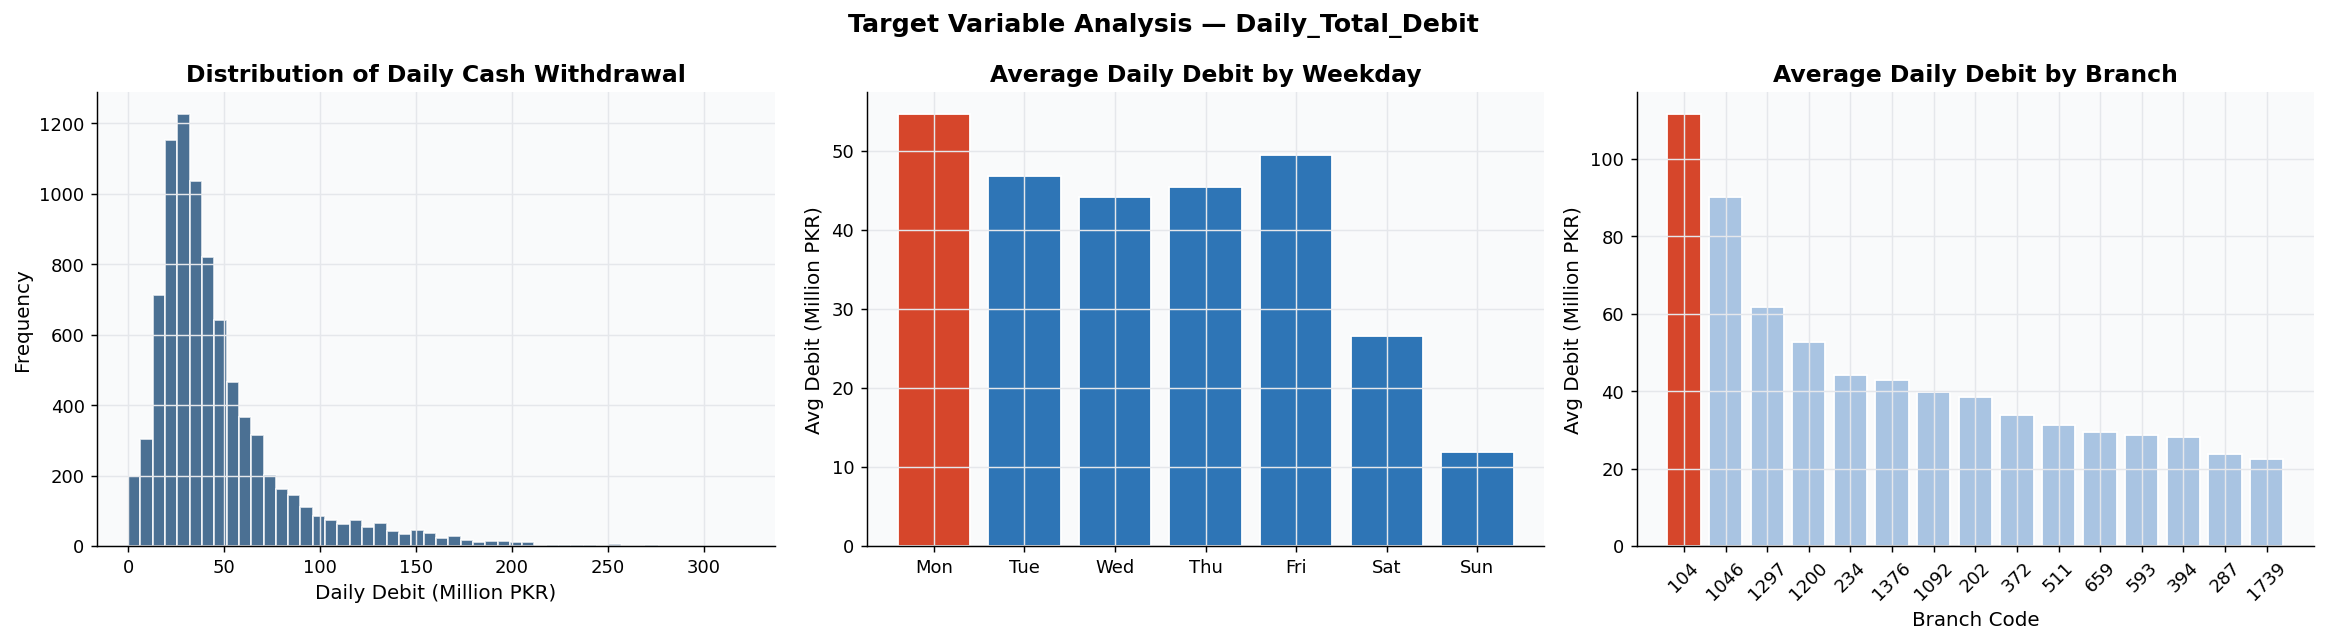

✅ Target analysis saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable Analysis — Daily_Total_Debit', fontsize=14, fontweight='bold')

# Distribution
axes[0].hist(daily['Daily_Total_Debit'] / 1e6, bins=50, color='#1F4E79', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution of Daily Cash Withdrawal')
axes[0].set_xlabel('Daily Debit (Million PKR)')
axes[0].set_ylabel('Frequency')

# By Weekday
wd_avg = daily.groupby('Weekday')['Daily_Total_Debit'].mean() / 1e6
days   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(range(len(wd_avg)), wd_avg.values,
            color=['#D6462B' if v == wd_avg.max() else '#2E75B6' for v in wd_avg.values],
            edgecolor='white')
axes[1].set_xticks(range(len(wd_avg)))
axes[1].set_xticklabels([days[i] for i in wd_avg.index])
axes[1].set_title('Average Daily Debit by Weekday')
axes[1].set_ylabel('Avg Debit (Million PKR)')

# By Branch
br_avg = daily.groupby('tran_br_code')['Daily_Total_Debit'].mean().sort_values(ascending=False) / 1e6
colors = ['#D6462B' if i == 0 else '#A9C4E2' for i in range(len(br_avg))]
axes[2].bar(br_avg.index.astype(str), br_avg.values, color=colors, edgecolor='white')
axes[2].set_title('Average Daily Debit by Branch')
axes[2].set_xlabel('Branch Code')
axes[2].set_ylabel('Avg Debit (Million PKR)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_plots/09_target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Target analysis saved.')

---
## Step 11 — Save Prepared Data

In [10]:
# Save train/test splits
X_train.to_csv('model_data/X_train.csv', index=False)
X_test.to_csv('model_data/X_test.csv',   index=False)
y_train.to_csv('model_data/y_train.csv', index=False)
y_test.to_csv('model_data/y_test.csv',   index=False)

# Save full daily dataset (for final model training on 100% data)
daily.to_csv('model_data/daily_full.csv', index=False)

# Save feature column list
import json
with open('model_data/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

print('✅ All files saved in model_data/ folder:')
print('   📄 X_train.csv      — Training features')
print('   📄 X_test.csv       — Test features')
print('   📄 y_train.csv      — Training target')
print('   📄 y_test.csv       — Test target')
print('   📄 daily_full.csv   — Full dataset (for final model)')
print('   📄 feature_cols.json — Feature list')

✅ All files saved in model_data/ folder:
   📄 X_train.csv      — Training features
   📄 X_test.csv       — Test features
   📄 y_train.csv      — Training target
   📄 y_test.csv       — Test target
   📄 daily_full.csv   — Full dataset (for final model)
   📄 feature_cols.json — Feature list


---
## ✅ Phase 3 Summary

| Item | Detail |
|---|---|
| **Target Variable** | `Daily_Total_Debit` (cash withdrawal per branch per day) |
| **Granularity** | Daily × Branch level |
| **Lag Features Added** | lag_1, lag_7, lag_14, lag_30, rolling_7, rolling_30 |
| **Total Features** | See feature list above |
| **Split Type** | Chronological (no shuffle) |
| **Train** | 80% — historical data |
| **Test** | 20% — recent data (validation only) |
| **Data Leakage** | ✅ None confirmed |

